Shrushti Sakat     
INTERNSHIP ID : IN226049402

---
## 📦 Step 0: Install & Import Required Libraries

In [29]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── NLP Libraries ───────────────────────────────────────────────────────────
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer

# Download required NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# ── Feature Engineering ─────────────────────────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# ── Machine Learning Models (Required) ─────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

# ── Model Evaluation ────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("All required libraries imported successfully!")

All required libraries imported successfully!


---
## Step 1: Data Understanding & Loading
We use the IMDb 50K dataset from Kaggle.

Required setup:
1. Download dataset from Kaggle: https://www.kaggle.com/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
2. Extract the file and keep `IMDB Dataset.csv`
3. Place it in the same folder as this notebook (or Downloads)
4. Run the next cell to load data

In [30]:
# ───────────────────────────────────────────────────────────────────────────
# LOAD DATA FROM LOCAL CSV – IMDb Dataset
# ───────────────────────────────────────────────────────────────────────────
import os

possible_paths = [
    "IMDB Dataset.csv",
    os.path.join(os.path.expanduser("~"), "Downloads", "IMDB Dataset.csv"),
    "IMDB_Dataset.csv",
    os.path.join(os.path.expanduser("~"), "Downloads", "IMDB_Dataset.csv"),
]

csv_path = next((path for path in possible_paths if os.path.exists(path)), None)
if csv_path is None:
    raise FileNotFoundError(
        "CSV file not found. Place 'IMDB Dataset.csv' in notebook folder or Downloads."
    )

print(f"Loading dataset from: {csv_path}")
df = pd.read_csv(csv_path)

# Keep only required columns and standardize values
df.columns = df.columns.str.lower().str.strip()
if "review" not in df.columns or "sentiment" not in df.columns:
    raise ValueError("CSV must contain 'review' and 'sentiment' columns")

df = df[["review", "sentiment"]].copy()
df["sentiment"] = df["sentiment"].astype(str).str.lower().str.strip()

# Shuffle dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset shape : {df.shape}")
print(f"Columns       : {df.columns.tolist()}")
print("Class counts:")
print(df["sentiment"].value_counts())
df.head()

Loading dataset from: IMDB Dataset.csv
Dataset shape : (50000, 2)
Columns       : ['review', 'sentiment']
Class counts:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,I really liked this Summerslam due to the look...,positive
1,Not many television shows appeal to quite as m...,positive
2,The film quickly gets to a major chase scene w...,negative
3,Jane Austen would definitely approve of this o...,positive
4,Expectations were somewhat high for me when I ...,negative



📊 Class Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Total Samples : 50000


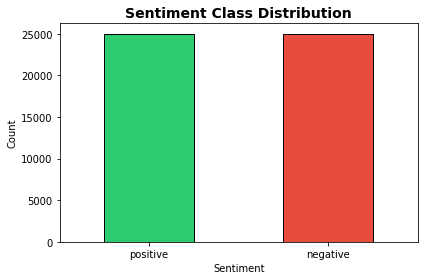


📏 Review Length Statistics:
             count       mean         std   min    25%    50%    75%     max
sentiment                                                                   
negative   25000.0  229.46456  164.947795   4.0  128.0  174.0  278.0  1522.0
positive   25000.0  232.84932  177.497046  10.0  125.0  172.0  284.0  2470.0


In [31]:
# ── Class Distribution ───────────────────────────────────────────────────────
print("\n📊 Class Distribution:")
print(df['sentiment'].value_counts())
print(f"\nTotal Samples : {len(df)}")

# Plot class distribution
plt.figure(figsize=(6, 4))
colors = ['#2ecc71', '#e74c3c']
df['sentiment'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Sentiment Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Review length analysis
df['review_length'] = df['review'].apply(lambda x: len(x.split()))
print("\n📏 Review Length Statistics:")
print(df.groupby('sentiment')['review_length'].describe())

---
## 🧹 Step 2: NLP Preprocessing
We build **reusable functions** for each preprocessing step as required.

In [32]:
# ── Initialize NLP Tools ─────────────────────────────────────────────────────
lemmatizer = WordNetLemmatizer()
stemmer    = PorterStemmer()
STOP_WORDS = set(stopwords.words('english'))

# ────────────────────────────────────────────────────────────────────────────
# REUSABLE PREPROCESSING FUNCTIONS
# ────────────────────────────────────────────────────────────────────────────

def to_lowercase(text):
    """Convert all characters in text to lowercase."""
    return text.lower()


def remove_urls(text):
    """Remove URLs and web links from text."""
    return re.sub(r'http\S+|www\.\S+', '', text)


def remove_special_characters(text):
    """Remove HTML tags, special characters, and digits."""
    text = re.sub(r'<.*?>', '', text)          # Remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)   # Keep only letters and spaces
    return text


def remove_punctuation(text):
    """Remove all punctuation from text."""
    return text.translate(str.maketrans('', '', string.punctuation))


def tokenize(text):
    """Tokenize text into individual words."""
    return word_tokenize(text)


def remove_stopwords(tokens):
    """Remove common stopwords from a list of tokens."""
    return [word for word in tokens if word not in STOP_WORDS]


def lemmatize_tokens(tokens):
    """Apply lemmatization to reduce words to their base/dictionary form."""
    return [lemmatizer.lemmatize(word) for word in tokens]


def stem_tokens(tokens):
    """Apply stemming to reduce words to their root form."""
    return [stemmer.stem(word) for word in tokens]


def full_preprocess(text, use_stemming=False):
    """
    Complete NLP preprocessing pipeline:
    1. Lowercase
    2. Remove URLs
    3. Remove special characters / HTML
    4. Remove punctuation
    5. Tokenize
    6. Remove stopwords
    7. Lemmatize (default) or Stem
    Returns a clean string.
    """
    text   = to_lowercase(text)
    text   = remove_urls(text)
    text   = remove_special_characters(text)
    text   = remove_punctuation(text)
    tokens = tokenize(text)
    tokens = remove_stopwords(tokens)
    if use_stemming:
        tokens = stem_tokens(tokens)
    else:
        tokens = lemmatize_tokens(tokens)
    return ' '.join(tokens)


print("✅ Preprocessing functions defined!")

# ── Demonstrate each step on a sample review ────────────────────────────────
sample = df['review'][0]
print(f"\nOriginal     : {sample}")
print(f"Lowercased   : {to_lowercase(sample)}")
print(f"No URLs      : {remove_urls(sample)}")
print(f"No Specials  : {remove_special_characters(to_lowercase(sample))}")
tokens = tokenize(remove_punctuation(remove_special_characters(to_lowercase(sample))))
print(f"Tokens       : {tokens[:10]} ...")
filtered = remove_stopwords(tokens)
print(f"No Stopwords : {filtered[:10]} ...")
lemmatized = lemmatize_tokens(filtered)
print(f"Lemmatized   : {lemmatized[:10]} ...")
print(f"\nFinal Clean  : {full_preprocess(sample)}")

✅ Preprocessing functions defined!

Original     : I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok to have a huge fat man vs a strong man but I'm glad times have changed. It was a terrible main event just like every match Luger is in is terrible. Other matches on the card were Razor Ramon vs Ted Dibiase, Steiner Brothers vs Heavenly Bodies, Shawn Michaels vs Curt Hening, this was the event where Shawn named his big monster of a body guard Diesel, IRS vs 1-2-3 Kid, Bret Hart first takes on Doink then takes on Jerry Lawler and stuff with the Harts and Lawler was always very interesting, then Ludvig Borga destroyed Marty Jannetty, Undertaker took on Giant Gonzalez in another terrible match, The Smoking Gunns and Tatanka took on Bam Bam Bigel

In [34]:
# ── Apply preprocessing to the entire dataset ────────────────────────────────
print("⏳ Preprocessing all reviews...")
df['cleaned_review'] = df['review'].apply(full_preprocess)

print("✅ Preprocessing complete!")
print("\nBefore vs After preprocessing:")
comparison = df[['review', 'cleaned_review']].head(3)
for i, row in comparison.iterrows():
    print(f"\n[{i}] ORIGINAL : {row['review']}")
    print(f"    CLEANED  : {row['cleaned_review']}")

⏳ Preprocessing all reviews...
✅ Preprocessing complete!

Before vs After preprocessing:

[0] ORIGINAL : I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok to have a huge fat man vs a strong man but I'm glad times have changed. It was a terrible main event just like every match Luger is in is terrible. Other matches on the card were Razor Ramon vs Ted Dibiase, Steiner Brothers vs Heavenly Bodies, Shawn Michaels vs Curt Hening, this was the event where Shawn named his big monster of a body guard Diesel, IRS vs 1-2-3 Kid, Bret Hart first takes on Doink then takes on Jerry Lawler and stuff with the Harts and Lawler was always very interesting, then Ludvig Borga destroyed Marty Jannetty, Undertaker took on Giant Gonzalez in another terrible matc

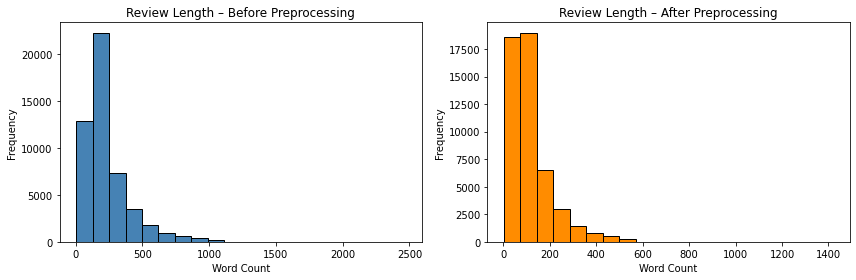

Average words before preprocessing: 231.2
Average words after  preprocessing: 118.6


In [35]:
# ── Word length analysis after preprocessing ─────────────────────────────────
df['cleaned_length'] = df['cleaned_review'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['review_length'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Review Length – Before Preprocessing')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['cleaned_length'], bins=20, color='darkorange', edgecolor='black')
axes[1].set_title('Review Length – After Preprocessing')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Average words before preprocessing: {df['review_length'].mean():.1f}")
print(f"Average words after  preprocessing: {df['cleaned_length'].mean():.1f}")

---
## 🔢 Step 3: Feature Engineering
We convert the cleaned text into numerical representations using **Bag of Words (BoW)** and **TF-IDF**.

In [36]:
# ── Encode target labels ─────────────────────────────────────────────────────
# positive → 1, negative → 0
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

X = df['cleaned_review']
y = df['label']

# ── Train-Test Split (80/20) ─────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

Training samples : 40000
Testing  samples : 10000


In [37]:
# ────────────────────────────────────────────────────────────────────────────
# VECTORIZATION 1: Bag of Words (BoW)
# Each document is represented as a word frequency vector.
# ────────────────────────────────────────────────────────────────────────────
bow_vectorizer = CountVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow  = bow_vectorizer.transform(X_test)

print(f"BoW Feature Matrix Shape – Train : {X_train_bow.shape}")
print(f"BoW Feature Matrix Shape – Test  : {X_test_bow.shape}")

# Display top 20 BoW features
bow_vocab = bow_vectorizer.get_feature_names_out()
print(f"\nSample BoW Features: {bow_vocab[:20].tolist()}")

BoW Feature Matrix Shape – Train : (40000, 5000)
BoW Feature Matrix Shape – Test  : (10000, 5000)

Sample BoW Features: ['abandoned', 'abc', 'ability', 'able', 'absence', 'absolute', 'absolutely', 'absolutely nothing', 'absurd', 'abuse', 'abysmal', 'academy', 'academy award', 'accent', 'accept', 'acceptable', 'accepted', 'accident', 'accidentally', 'accompanied']


In [39]:
# ────────────────────────────────────────────────────────────────────────────
# VECTORIZATION 2: TF-IDF (Term Frequency – Inverse Document Frequency)
# Weighs terms by how important they are relative to the whole corpus.
# ────────────────────────────────────────────────────────────────────────────
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF Feature Matrix Shape – Train : {X_train_tfidf.shape}")
print(f"TF-IDF Feature Matrix Shape – Test  : {X_test_tfidf.shape}")

# Display top 20 TF-IDF features
tfidf_vocab = tfidf_vectorizer.get_feature_names_out()
print(f"\nSample TF-IDF Features: {tfidf_vocab[:20].tolist()}")

TF-IDF Feature Matrix Shape – Train : (40000, 5000)
TF-IDF Feature Matrix Shape – Test  : (10000, 5000)

Sample TF-IDF Features: ['abandoned', 'abc', 'ability', 'able', 'absence', 'absolute', 'absolutely', 'absolutely nothing', 'absurd', 'abuse', 'abysmal', 'academy', 'academy award', 'accent', 'accept', 'acceptable', 'accepted', 'accident', 'accidentally', 'accompanied']


---
## Step 4: Model Building
Train the 3 required models on both BoW and TF-IDF features:
- Logistic Regression
- Naive Bayes
- Decision Tree

In [40]:
# ────────────────────────────────────────────────────────────────────────────
# Helper function to train a model and return evaluation metrics
# ────────────────────────────────────────────────────────────────────────────
def train_and_evaluate(model, X_train_vec, X_test_vec, y_train, y_test, model_name, vectorizer_name):
    """
    Train the given model, make predictions, and return a dictionary
    of evaluation metrics.
    """
    # Train
    model.fit(X_train_vec, y_train)

    # Predict
    y_pred = model.predict(X_test_vec)

    # Metrics
    metrics = {
        'Model'       : model_name,
        'Vectorizer'  : vectorizer_name,
        'Accuracy'    : round(accuracy_score(y_test, y_pred), 4),
        'Precision'   : round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'      : round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1 Score'    : round(f1_score(y_test, y_pred, zero_division=0), 4),
    }

    return metrics, y_pred


print("✅ Evaluation helper function defined.")

✅ Evaluation helper function defined.


In [41]:
# ── Define required models (at least 3) ─────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
}

# ── Vectorizer configurations ────────────────────────────────────────────────
vectorizers = {
    'BoW': (X_train_bow, X_test_bow),
    'TF-IDF': (X_train_tfidf, X_test_tfidf),
}

# ── Train and collect all results ────────────────────────────────────────────
all_results = []

for vec_name, (X_tr, X_te) in vectorizers.items():
    print(f"\n{'='*55}")
    print(f"  Vectorizer: {vec_name}")
    print(f"{'='*55}")

    for model_name, model in models.items():
        metrics, _ = train_and_evaluate(
            model, X_tr, X_te, y_train, y_test, model_name, vec_name
        )
        all_results.append(metrics)
        print(
            f"  {model_name:<20} | "
            f"Acc: {metrics['Accuracy']:.4f} | "
            f"P: {metrics['Precision']:.4f} | "
            f"R: {metrics['Recall']:.4f} | "
            f"F1: {metrics['F1 Score']:.4f}"
        )

results_df = pd.DataFrame(all_results)
print("\nAll required models trained and evaluated!")


  Vectorizer: BoW
  Logistic Regression  | Acc: 0.8777 | P: 0.8773 | R: 0.8782 | F1: 0.8778
  Naive Bayes          | Acc: 0.8540 | P: 0.8547 | R: 0.8530 | F1: 0.8539
  Decision Tree        | Acc: 0.7283 | P: 0.6851 | R: 0.8450 | F1: 0.7567

  Vectorizer: TF-IDF
  Logistic Regression  | Acc: 0.8908 | P: 0.8840 | R: 0.8996 | F1: 0.8918
  Naive Bayes          | Acc: 0.8616 | P: 0.8563 | R: 0.8690 | F1: 0.8626
  Decision Tree        | Acc: 0.7323 | P: 0.6871 | R: 0.8530 | F1: 0.7611

All required models trained and evaluated!


---
## 📈 Step 5: Model Evaluation

In [42]:
# ── Results Table: Accuracy, Precision, Recall, F1 ──────────────────────────
results_sorted = results_df.sort_values('F1 Score', ascending=False).reset_index(drop=True)
print(results_sorted.to_string(index=False))

              Model Vectorizer  Accuracy  Precision  Recall  F1 Score
Logistic Regression     TF-IDF    0.8908     0.8840  0.8996    0.8918
Logistic Regression        BoW    0.8777     0.8773  0.8782    0.8778
        Naive Bayes     TF-IDF    0.8616     0.8563  0.8690    0.8626
        Naive Bayes        BoW    0.8540     0.8547  0.8530    0.8539
      Decision Tree     TF-IDF    0.7323     0.6871  0.8530    0.7611
      Decision Tree        BoW    0.7283     0.6851  0.8450    0.7567


---
## 🔍 Step 6: Comparison & Insights

In [44]:
# ── Comparison & Insights Summary ────────────────────────────────────────────
best_overall = results_df.sort_values('F1 Score', ascending=False).iloc[0]

print("Best configuration based on F1 score:")
print(f"Model      : {best_overall['Model']}")
print(f"Vectorizer : {best_overall['Vectorizer']}")
print(f"Accuracy   : {best_overall['Accuracy']}")
print(f"Precision  : {best_overall['Precision']}")
print(f"Recall     : {best_overall['Recall']}")
print(f"F1 Score   : {best_overall['F1 Score']}")

Best configuration based on F1 score:
Model      : Logistic Regression
Vectorizer : TF-IDF
Accuracy   : 0.8908
Precision  : 0.884
Recall     : 0.8996
F1 Score   : 0.8918
